# Source Distribution Verification

Verifies that `openmc.stats.SphericalIndependent` with `PowerLaw(0, R, 2)` produces a **uniform distribution within the sphere**.

### Why does `PowerLaw(0, R, 2)` give a uniform sphere?

The volume element in spherical coordinates is:
$$dV = r^2 \, dr \, d(\cos\theta) \, d\phi$$

So for uniform density we need the three marginal distributions:
- $r$: $p(r) \propto r^2$ — exactly what `PowerLaw(0, R, 2)` samples
- $\cos\theta$: uniform on $[-1, 1]$ — `Uniform(-1, 1)`
- $\phi$: uniform on $[0, 2\pi]$ — `Uniform(0, 2\pi)`

Using `Uniform(0, R)` for $r$ instead would **over-populate the centre** (the naive mistake).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

N = 200_000
R = 3.0  # cm — matches rossi_meshing.py core radius

rng = np.random.default_rng(42)
u = rng.random((3, N))

# PowerLaw(0, R, 2): p(r) ∝ r²
# CDF: F(r) = (r/R)³  →  inverse CDF: r = R * u^(1/3)
r         = R * u[0] ** (1 / 3)
cos_theta = 2 * u[1] - 1          # Uniform(-1, 1)
phi       = 2 * np.pi * u[2]      # Uniform(0, 2π)

sin_theta = np.sqrt(1 - cos_theta**2)
x = r * sin_theta * np.cos(phi)
y = r * sin_theta * np.sin(phi)
z = r * cos_theta

radii = np.sqrt(x**2 + y**2 + z**2)
print(f"All points inside sphere: {np.all(radii <= R + 1e-10)}")
print(f"Max radius: {radii.max():.6f} cm  (should be ≤ {R} cm)")

All points inside sphere: True
Max radius: 2.999998 cm  (should be ≤ 3.0 cm)


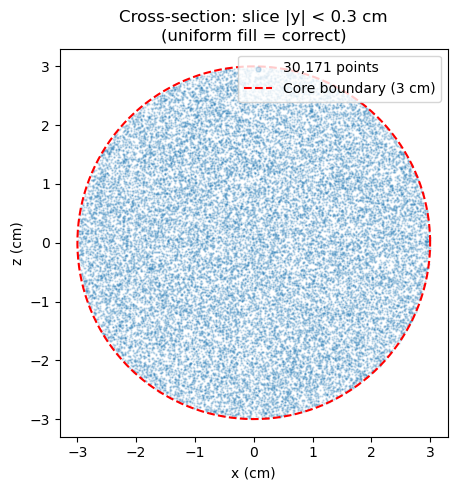

In [2]:
# --- Spatial check: 2D cross-section ---
# A thin slice through the y≈0 plane. If the distribution is truly uniform,
# the filled circle should have no density gradient (no crowding at centre or edge).

mask = np.abs(y) < 0.3  # ~10% slice thickness
theta_ring = np.linspace(0, 2 * np.pi, 300)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(x[mask], z[mask], s=0.5, alpha=0.2, rasterized=True, label=f"{mask.sum():,} points")
ax.plot(R * np.cos(theta_ring), R * np.sin(theta_ring), "r--", lw=1.5, label="Core boundary (3 cm)")
ax.set_aspect("equal")
ax.set_xlabel("x (cm)")
ax.set_ylabel("z (cm)")
ax.set_title("Cross-section: slice |y| < 0.3 cm\n(uniform fill = correct)")
ax.legend(markerscale=5)
plt.tight_layout()
plt.show()

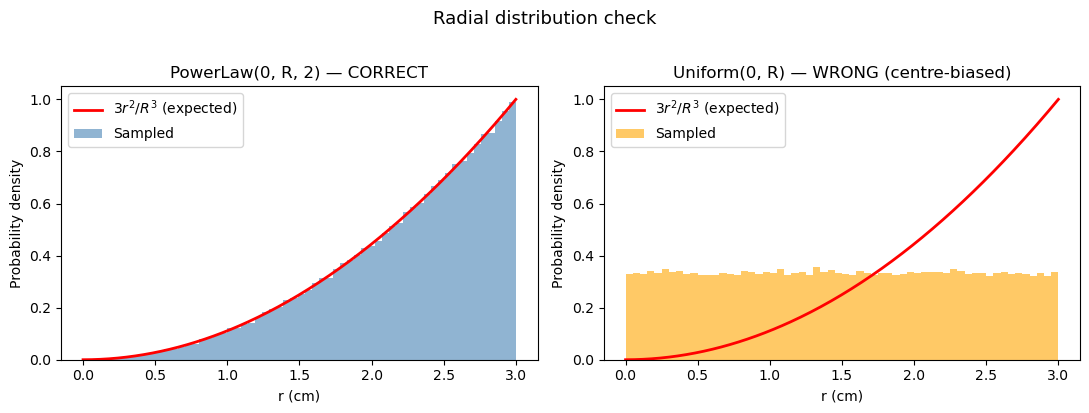

In [3]:
# --- Radial histogram: correct vs. naive ---
# Left:  PowerLaw(0, R, 2) — bars should follow the red r² curve
# Right: naive Uniform(0, R) — bars are flat but r² curve rises → centre-biased

r_wrong = R * np.random.default_rng(0).random(N)  # naive approach

r_theory = np.linspace(0, R, 300)
norm = 3 / R**3  # normalisation: ∫₀ᴿ (3/R³) r² dr = 1

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)

for ax, r_data, color, title in [
    (axes[0], r,       "steelblue", "PowerLaw(0, R, 2) — CORRECT"),
    (axes[1], r_wrong, "orange",    "Uniform(0, R) — WRONG (centre-biased)"),
]:
    counts, edges = np.histogram(r_data, bins=60, density=True)
    r_mid = 0.5 * (edges[:-1] + edges[1:])
    ax.bar(r_mid, counts, width=np.diff(edges), alpha=0.6, color=color, label="Sampled")
    ax.plot(r_theory, norm * r_theory**2, "r-", lw=2, label=r"$3r^2/R^3$ (expected)")
    ax.set_xlabel("r (cm)")
    ax.set_ylabel("Probability density")
    ax.set_title(title)
    ax.legend()

plt.suptitle("Radial distribution check", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()